In [1]:
import matplotlib.pyplot as plt
import pandas as pd

### 1. Load Processed Data
Load the final data from `processed_air_quality_data.csv` and ensure the 'date' column is in the correct datetime format for plotting.

In [2]:
# Load the processed data
final_df = pd.read_csv('processed_air_quality_data.csv', low_memory=False)
final_df['date'] = pd.to_datetime(final_df['date'])

### 2. Distribution of Pollutant Levels
Histograms visualize the distribution of the pollutants. A log scale is used on the y-axis to better handle the wide range of frequency values.

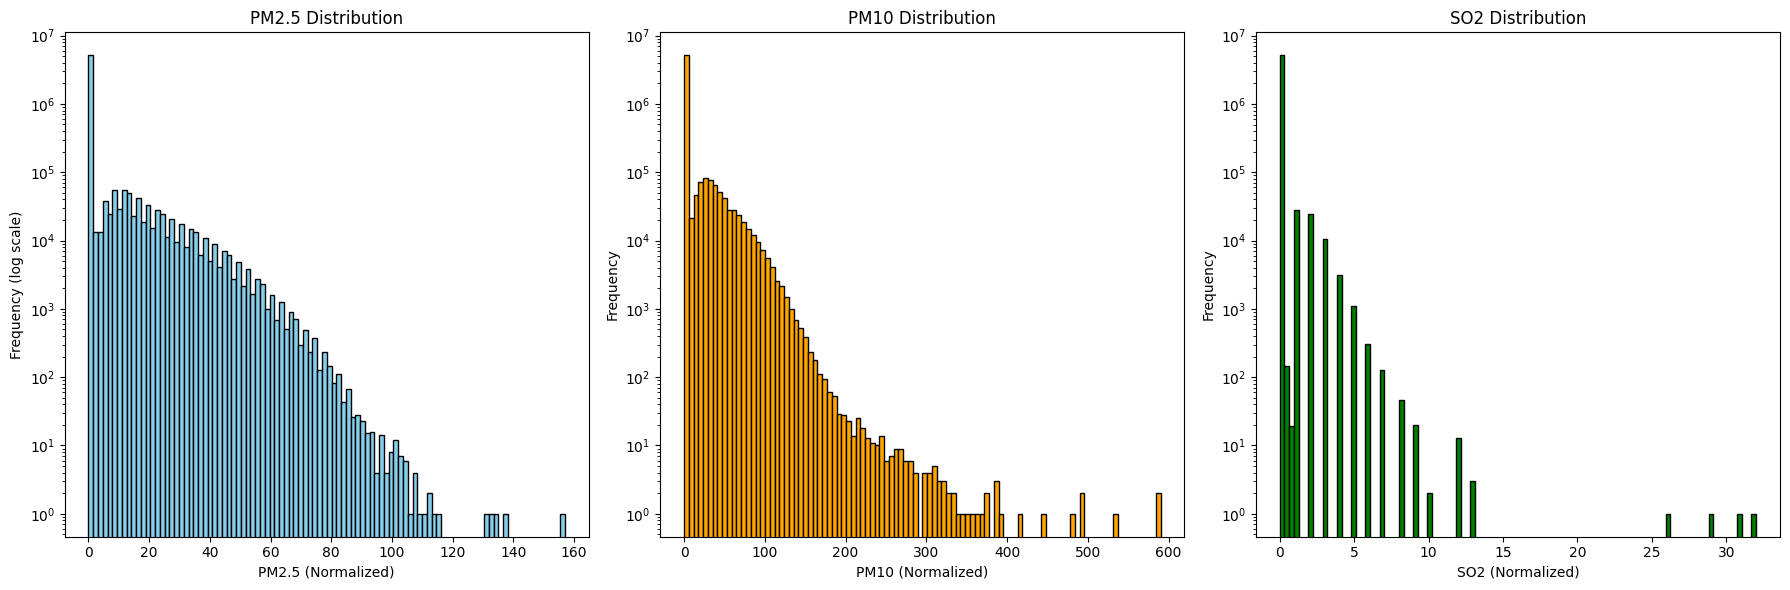

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

final_df['pm2.5_avg'].plot(kind='hist', bins=100, ax=axes[0], log=True, color='skyblue', edgecolor='black')
axes[0].set_title('PM2.5 Distribution')
axes[0].set_xlabel('PM2.5 (Normalized)')
axes[0].set_ylabel('Frequency (log scale)')

final_df['pm10_avg'].plot(kind='hist', bins=100, ax=axes[1], log=True, color='orange', edgecolor='black')
axes[1].set_title('PM10 Distribution')
axes[1].set_xlabel('PM10 (Normalized)')

final_df['so2_avg'].plot(kind='hist', bins=100, ax=axes[2], log=True, color='green', edgecolor='black')
axes[2].set_title('SO2 Distribution')
axes[2].set_xlabel('SO2 (Normalized)')

plt.tight_layout()
plt.show()

### 3. Identifying Outliers in Pollutant Levels
Box plots are used to show the data spread and identify potential outliers for each pollutant.

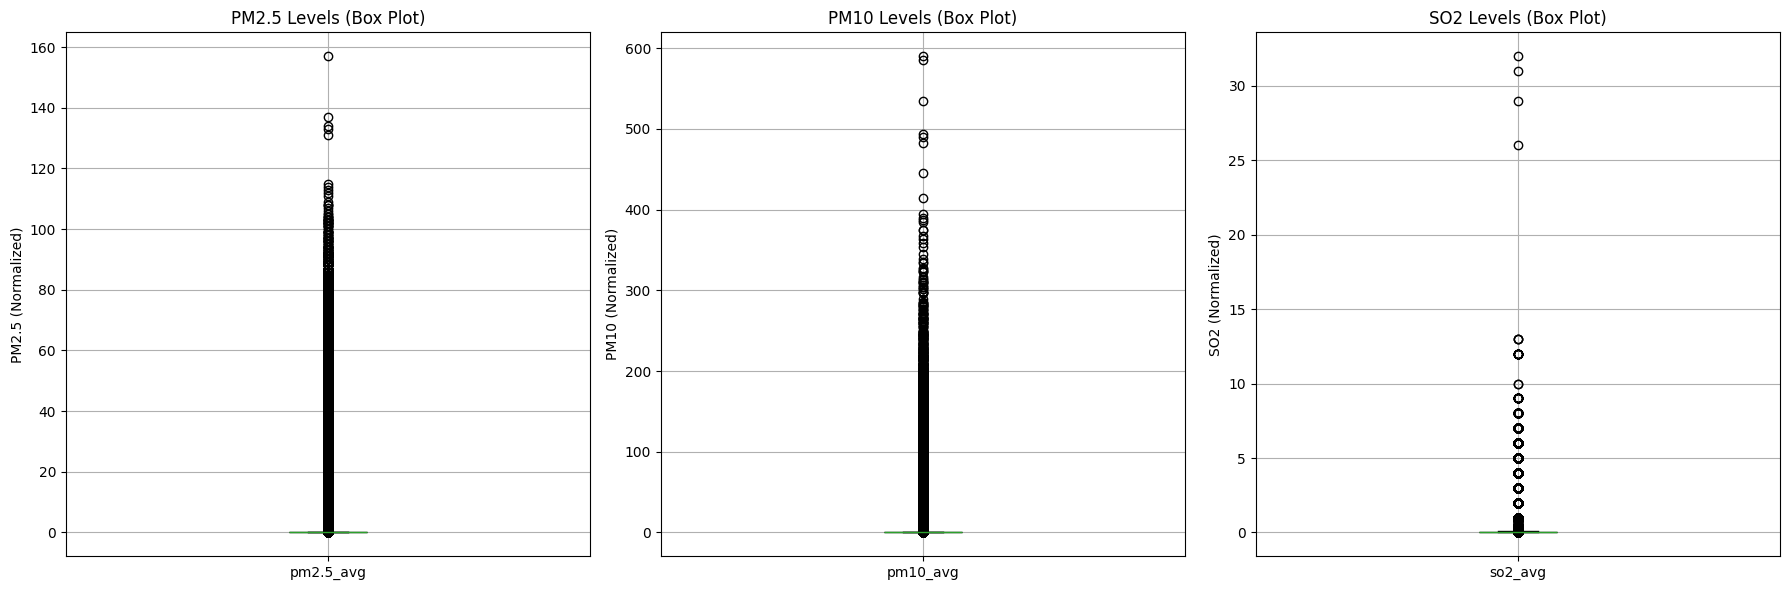

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

final_df.boxplot(column='pm2.5_avg', ax=axes[0], patch_artist=True, boxprops=dict(facecolor='skyblue'))
axes[0].set_title('PM2.5 Levels (Box Plot)')
axes[0].set_ylabel('PM2.5 (Normalized)')

final_df.boxplot(column='pm10_avg', ax=axes[1], patch_artist=True, boxprops=dict(facecolor='orange'))
axes[1].set_title('PM10 Levels (Box Plot)')
axes[1].set_ylabel('PM10 (Normalized)')

final_df.boxplot(column='so2_avg', ax=axes[2], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[2].set_title('SO2 Levels (Box Plot)')
axes[2].set_ylabel('SO2 (Normalized)')

plt.tight_layout()
plt.show()

### 4. Air Quality Trends Over Time (Rolling Mean)
A 30-day rolling mean is plotted to smooth out daily fluctuations and reveal longer-term trends in pollution levels.

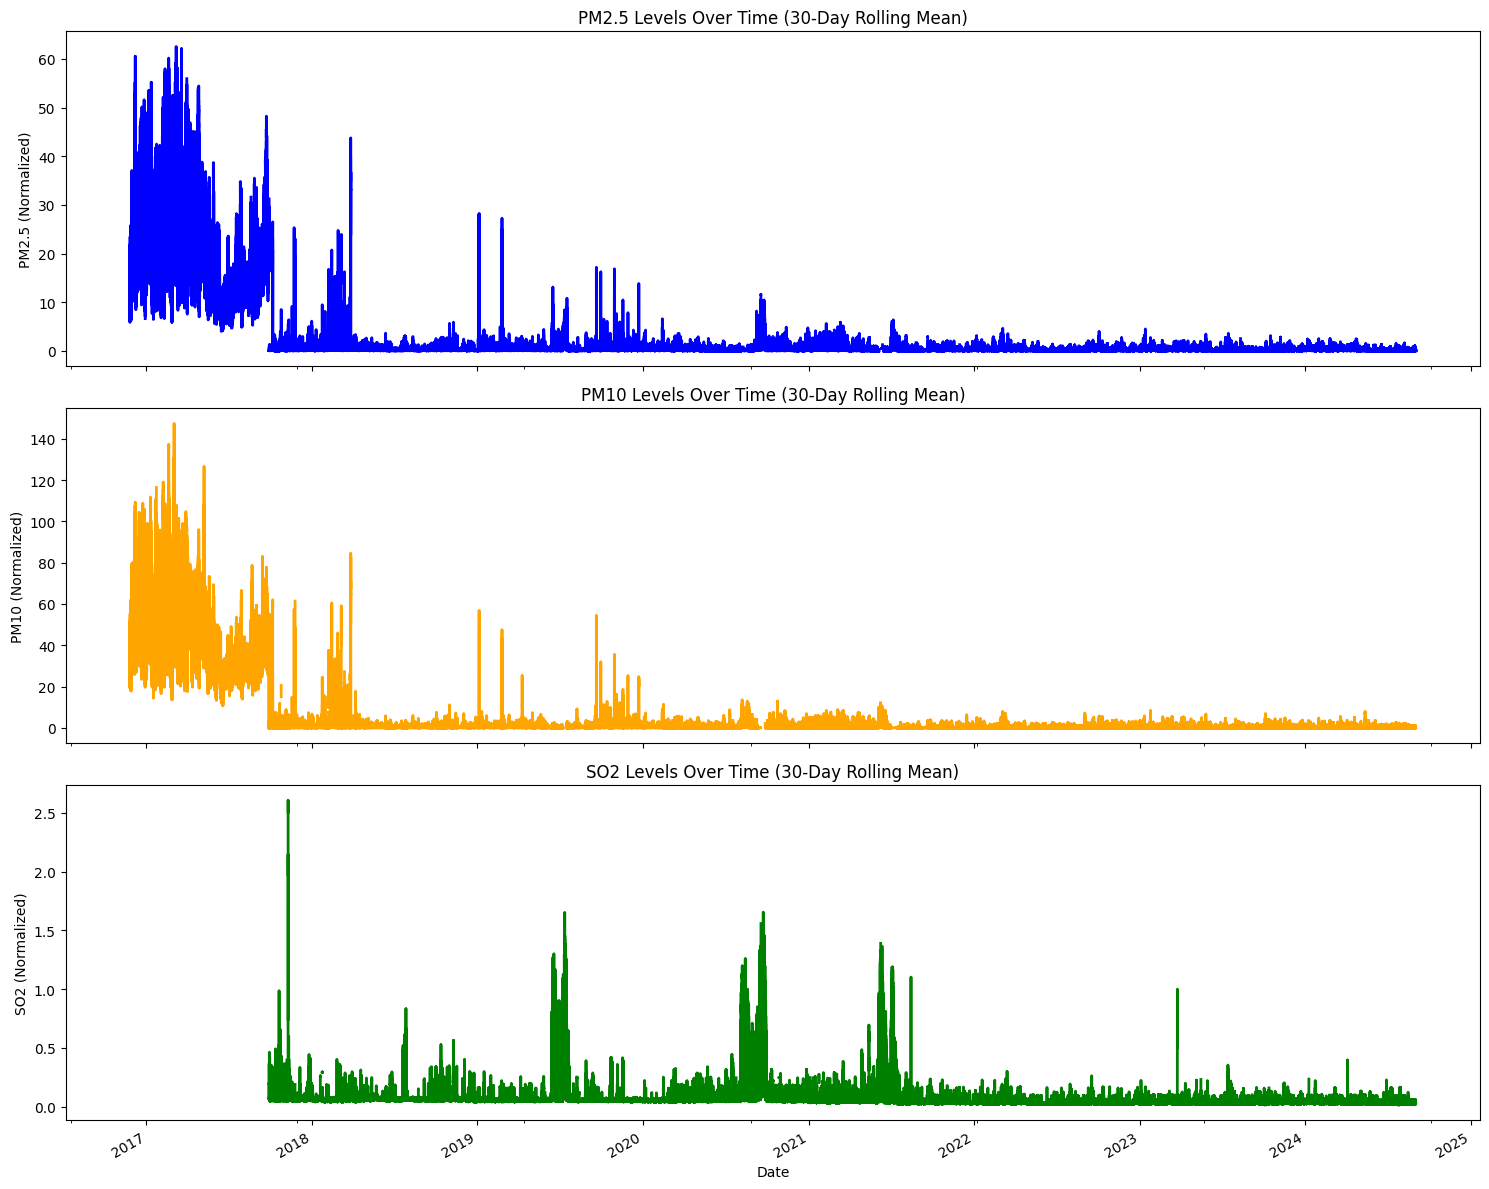

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
window_size = 30

# Aggregate by date to avoid mixing stations and ensure chronological order
trend_df = (
    final_df.sort_values('date')
    .groupby('date')[['pm2.5_avg', 'pm10_avg', 'so2_avg']]
    .mean()
)

trend_df['pm2.5_avg'].rolling(window=window_size).mean().plot(ax=axes[0], color='blue', linewidth=2)
axes[0].set_title(f'PM2.5 Levels Over Time ({window_size}-Day Rolling Mean)')
axes[0].set_ylabel('PM2.5 (Normalized)')

trend_df['pm10_avg'].rolling(window=window_size).mean().plot(ax=axes[1], color='orange', linewidth=2)
axes[1].set_title(f'PM10 Levels Over Time ({window_size}-Day Rolling Mean)')
axes[1].set_ylabel('PM10 (Normalized)')

trend_df['so2_avg'].rolling(window=window_size).mean().plot(ax=axes[2], color='green', linewidth=2)
axes[2].set_title(f'SO2 Levels Over Time ({window_size}-Day Rolling Mean)')
axes[2].set_ylabel('SO2 (Normalized)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

### 5. Seasonal Variations of Pollutants
This plot shows the average pollutant concentrations for each month, revealing any seasonal patterns in air quality.

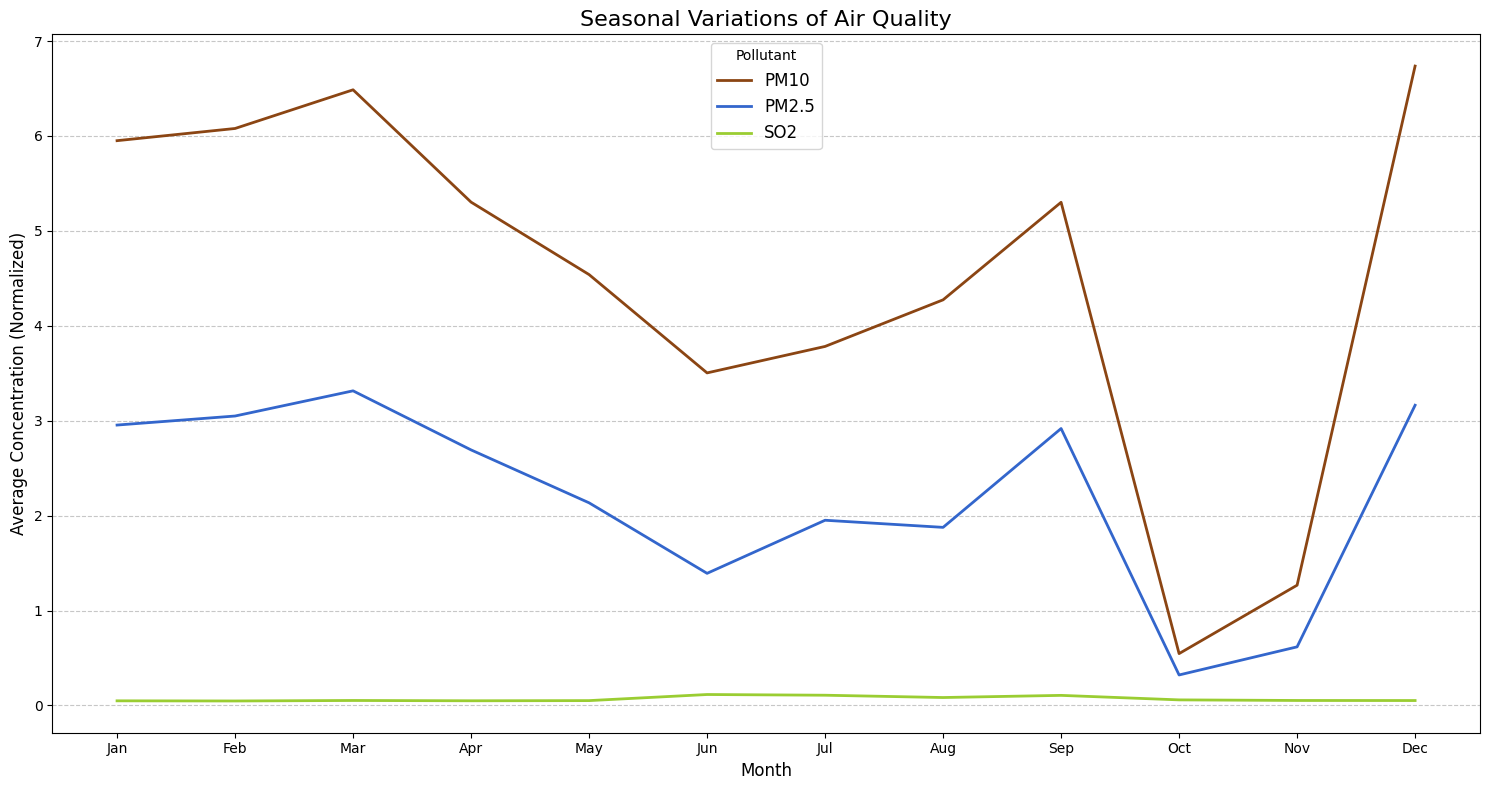

In [ ]:
final_df['month'] = final_df['date'].dt.month

# Average per county first to reduce sampling bias, then average across counties
monthly_by_county = (
    final_df.groupby(['county', 'month'])[['pm10_avg', 'pm2.5_avg', 'so2_avg']]
    .mean()
    .reset_index()
)
monthly_means = monthly_by_county.groupby('month')[['pm10_avg', 'pm2.5_avg', 'so2_avg']].mean()

plt.figure(figsize=(15, 8))

monthly_means['pm10_avg'].plot(label='PM10', color='#8B4513', linewidth=2)
monthly_means['pm2.5_avg'].plot(label='PM2.5', color='#3366CC', linewidth=2)
monthly_means['so2_avg'].plot(label='SO2', color='#9ACD32', linewidth=2)

plt.title('Seasonal Variations of Air Quality', fontsize=16)
plt.ylabel('Average Concentration (Normalized)', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Pollutant', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

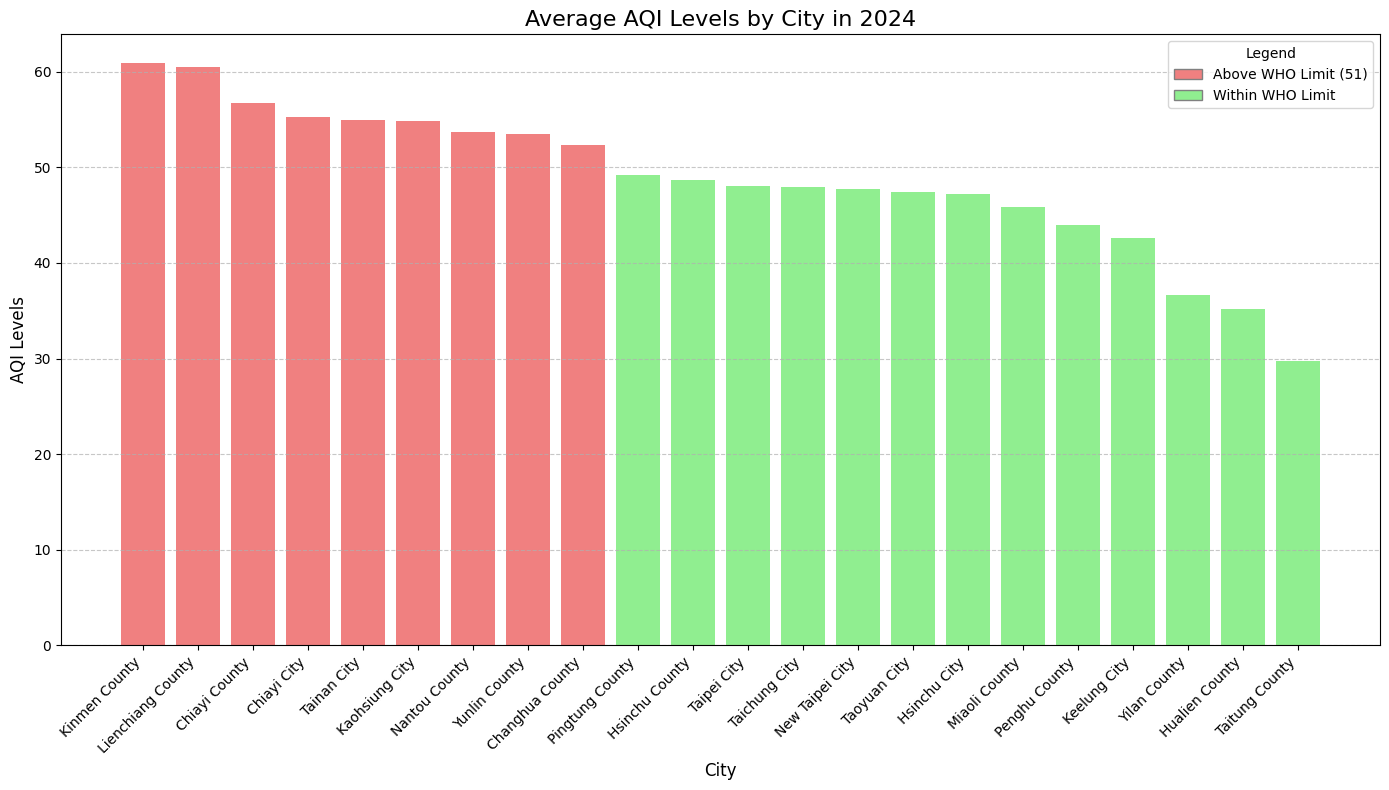

In [8]:
from matplotlib.patches import Patch

# Ensure city and AQI columns exist and Year has been extracted.
df_2024 = final_df[final_df['year'] == 2024]
aqi_by_city_2024 = df_2024.groupby('county')['aqi'].mean().sort_values(ascending=False)

# Define WHO limit and colors
who_limit = 51
colors = ['lightcoral' if x > who_limit else 'lightgreen' for x in aqi_by_city_2024]

plt.figure(figsize=(14, 8))
bars = plt.bar(aqi_by_city_2024.index, aqi_by_city_2024.values, color=colors)

plt.ylabel('AQI Levels', fontsize=12)
plt.xlabel('City', fontsize=12)
plt.title('Average AQI Levels by City in 2024', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Create a custom legend
legend_elements = [Patch(facecolor='lightcoral', edgecolor='grey', label='Above WHO Limit (51)'),
                   Patch(facecolor='lightgreen', edgecolor='grey', label='Within WHO Limit')]
plt.legend(handles=legend_elements, title='Legend')

plt.tight_layout()
plt.show()